## What is Simple Linear Regression?
Simple Linear Regression is finding the best relationship between the input variable x (independent variable) and the expected variable y (dependent variable). The linear relationship between these two variables can be represented by a straight line called regression line.

Formula :- $y = b0 + b1x$

What do terms represent?
- $y$ is the response or the target variable
- $x$ is the feature
- $b1$ is the coefficient of x
- $b0$ is the intercept

#### Estimating ("Learning") Model Coefficients

The coefficients are estimated using the **least-squares criterion**,  i.e.,
the best fit line has to be calculated that minimizes the **sum of squared residuals** (or "sum of squared errors").

## Diving into the code

## Dividing the code into steps for better understanding:
1. Load the dataset.
2. Visualize the data.
3. Training Simple Linear Regression Model.

## Step1 : Load Dataset

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
dataset = pd.read_csv('Salary_Data.csv')

In [3]:
dataset.head()

,YearsExperience,Salary
0,1.1,39343
1,1.3,46205
2,1.5,37731
3,2.0,43525
4,2.2,39891


In [4]:
dataset.shape

(30, 2)

Here, 'YearsExperience' is the independent variable and 'Salary' is the dependent variable which will be predicted based on the value of 'YearsExperience'.

In [5]:
X = dataset.drop(['Salary'],axis=True) #Features
y = dataset['Salary'] #Output classifications

In [27]:
#Now Split The Data
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.4,random_state=42)

In [28]:
X_train.shape,X_test.shape,y_train.shape,y_test.shape

((18, 1), (12, 1), (18,), (12,))

## Step 2: Visualize the data.

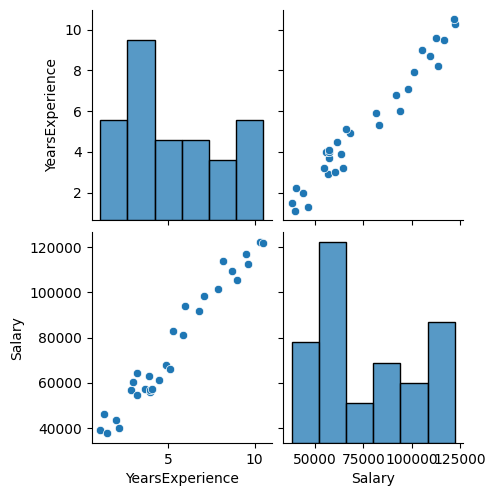

In [29]:
# Visualize Whole Data set
sns.pairplot(dataset)

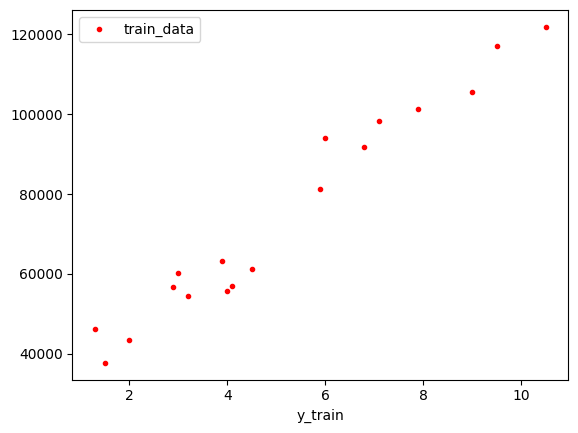

In [30]:
# Visualize Only Train data
plt.plot(X_train,y_train,'r.',label='train_data')
plt.xlabel('X_train')
plt.xlabel('y_train')
plt.legend()
plt.show()

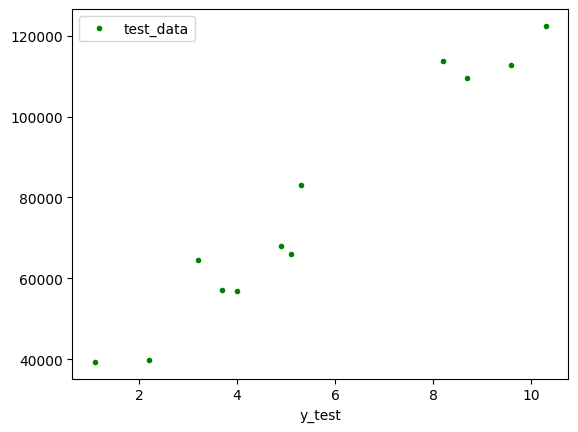

In [31]:
# Visualize Only Test data
plt.plot(X_test,y_test,'g.',label='test_data')
plt.xlabel('X_test')
plt.xlabel('y_test')
plt.legend()
plt.show()

In The Above three graph clealr shows that the data is linearly deparable so here we use Linear Regression

#### Ok, now we hope the dataset is pretty clear by now. We will move to the next step now!

## Step 3 :Training Simple Linear Regression Model.

In [32]:
from sklearn.linear_model import LinearRegression
regressor = LinearRegression()
regressor.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


### Predicting the Test set results

In [33]:
y_pred = regressor.predict(X_test).round(1)

In [34]:
calculation = pd.DataFrame(np.c_[y_test,y_pred], columns = ["Original Salary","Predict Salary"])
calculation

,Original Salary,Predict Salary
0,112635.0,115941.4
1,67938.0,72302.5
2,113812.0,102942.6
3,83088.0,76016.5
4,64445.0,56518.2
5,57189.0,61160.7
6,122391.0,122440.8
7,109431.0,107585.0
8,56957.0,63946.1
9,39343.0,37020.0


In [35]:
print("Training Accuracy :", regressor.score(X_train, y_train))
print("Testing Accuracy :", regressor.score(X_test, y_test))

Training Accuracy : 0.959168485203858
Testing Accuracy : 0.9532338376280692


## Visualising the Training set results

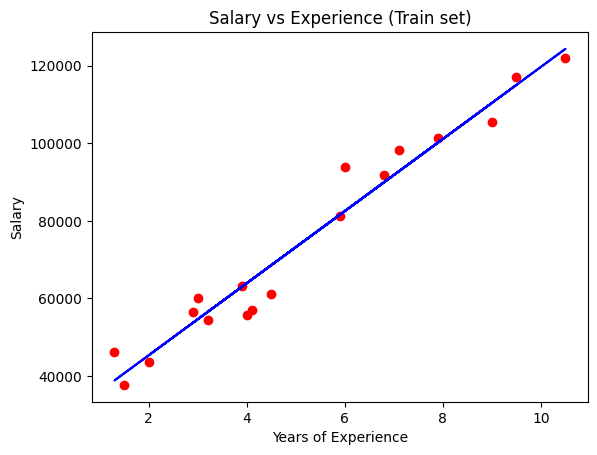

In [36]:
plt.scatter(X_train, y_train, color = 'red')
plt.plot(X_train, regressor.predict(X_train), color = 'blue')
plt.title('Salary vs Experience (Train set)')
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.show()

## Visualising the Training set results

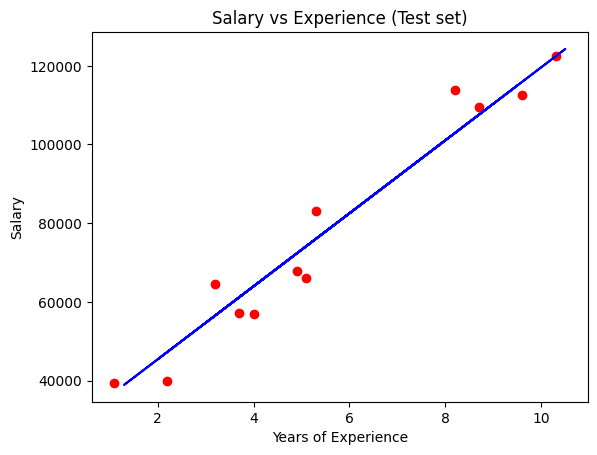

In [37]:
plt.scatter(X_test, y_test, color = 'red')
plt.plot(X_train, regressor.predict(X_train), color = 'blue')
plt.title('Salary vs Experience (Test set)')
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.show()

### This is All About Simple Linear Regresion . 